# Privacy Toolkit — analysis notebook

Story: **hashing names is not anonymization.** We generate synthetic people, measure how unique they are on quasi-identifiers, show that unsalted hashes crack, replace identifiers with HMAC tokens, then actually anonymize (k-anonymity + l-diversity) and attack both releases with a fake voter list.

Prefer `python src/run_pipeline.py` for a full regenerate of `reports/`. This notebook walks through the same argument with the saved artifacts.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd

ROOT = Path("..").resolve() if Path("../src").exists() else Path(".").resolve()
sys.path.insert(0, str(ROOT / "src"))

from anonymize import anonymize
from paths import ANON_CSV, PSEUDO_CSV, RAW_CSV, REPORTS_DIR
from risk_metrics import summarize_risk
from utility import compare_utility, salary_by_age_band

raw = pd.read_csv(RAW_CSV, dtype={"zip_code": str}, keep_default_na=False)
print(raw.shape)
raw.head()

(5000, 10)


,record_id,name,email,phone,age,zip_code,gender,job_title,medical_condition,salary
0,1,Mark Johnson,mark.johnson98@yahoo.com,(133) 218-1960,36,94145,Male,Data Analyst,No Condition,78642
1,2,Brandon Hall,brandon.hall77@hotmail.com,(108) 386-3794,51,10041,Male,Accountant,Asthma,67292
2,3,Peter Moore,peter.moore85@yahoo.com,(654) 235-1161,54,75215,Male,Data Analyst,Hypertension,76557
3,4,Ryan Munoz,ryan.munoz79@gmail.com,(478) 161-8495,49,98101,Male,Nurse,No Condition,79932
4,5,Michele Williams,michele.williams15@gmail.com,(641) 316-4752,26,10041,Female,Teacher,No Condition,73819


## 1. Baseline risk

Direct identifiers (name, email, phone) are obvious. **Quasi-identifiers** (age, ZIP, gender) are enough to single people out — that is the Sweeney result. Count equivalence classes on those three fields.

In [2]:
baseline = summarize_risk(raw)
baseline

{'quasi_identifiers': ['age', 'zip_code', 'gender'],
 'n_records': 5000,
 'n_equivalence_classes': 2498,
 'n_unique_classes': 1333,
 'n_unique_records': 1333,
 'pct_unique': 26.66,
 'min_k': 1,
 'median_class_size': 1.0,
 'pct_below_k5': 77.98,
 'prosecutor_risk': 1.0,
 'achieved_l': 1}

## 2. Unsalted hashing vs HMAC

`reports/pseudonymization_results.json` is written by the dictionary-attack script. Unsalted SHA-256 of emails is just a lookup table. HMAC with a secret key is not.

In [3]:
pseudo_attack = json.loads((REPORTS_DIR / "pseudonymization_results.json").read_text())
pseudo_attack

{'roster_coverage': 0.6,
 'roster_names': 3000,
 'records_with_known_name': 3094,
 'domains_guessed': ['gmail.com',
  'yahoo.com',
  'hotmail.com',
  'outlook.com',
  'aol.com'],
 'guesses_tried': 1470000,
 'unsalted_sha256': {'cracked': 3094,
  'of': 5000,
  'pct': 61.88,
  'seconds': 5.44},
 'keyed_hmac': {'cracked': 0,
  'of': 5000,
  'pct': 0.0,
  'seconds': 6.19,
  'guesses_tried': 1470000},
 'pct_unique_after_pseudonymization': 26.66}

## 3. Pseudonymized release

Names are gone. Age, ZIP, and gender are not. Linkage risk is unchanged.

In [4]:
pseudo = pd.read_csv(PSEUDO_CSV, dtype={"zip_code": str}, keep_default_na=False)
print(pseudo.columns.tolist())
print("unique on age, ZIP, gender:", summarize_risk(pseudo)["pct_unique"], "%")
pseudo.head(3)

['person_token', 'age', 'zip_code', 'gender', 'job_title', 'medical_condition', 'salary']
unique on age, ZIP, gender: 26.66 %


,person_token,age,zip_code,gender,job_title,medical_condition,salary
0,3cb37c04d063c1e7,36,94145,Male,Data Analyst,No Condition,78642
1,8fdfc1b371eaeb35,51,10041,Male,Accountant,Asthma,67292
2,662e60a602e720b5,54,75215,Male,Data Analyst,Hypertension,76557


## 4. Anonymized release (k = 5, l = 2)

Age → bands, ZIP → 3 digits, drop classes that are too small or not diverse on `medical_condition`.

In [5]:
anon = pd.read_csv(ANON_CSV, dtype={"zip3": str}, keep_default_na=False)
anon_stats = json.loads((REPORTS_DIR / "anonymization_results.json").read_text())
print(anon.shape)
anon_stats

(4935, 6)


{'k': 5,
 'l': 2,
 'n_in': 5000,
 'n_after_generalization': 5000,
 'n_after_k': 4935,
 'n_out': 4935,
 'suppressed': 65,
 'suppression_rate': 1.3,
 'achieved_k': 5,
 'achieved_l': 3,
 'risk_after': {'quasi_identifiers': ['age_band', 'zip3', 'gender'],
  'n_records': 4935,
  'n_equivalence_classes': 77,
  'n_unique_classes': 0,
  'n_unique_records': 0,
  'pct_unique': 0.0,
  'min_k': 5,
  'median_class_size': 58.0,
  'pct_below_k5': 0.0,
  'prosecutor_risk': 0.2,
  'achieved_l': 3},
 'risk_after_generalization_only': {'quasi_identifiers': ['age_band',
   'zip3',
   'gender'],
  'n_records': 5000,
  'n_equivalence_classes': 103,
  'n_unique_classes': 7,
  'n_unique_records': 7,
  'pct_unique': 0.14,
  'min_k': 1,
  'median_class_size': 38.0,
  'pct_below_k5': 1.3,
  'prosecutor_risk': 1.0,
  'achieved_l': 1}}

## 5. Linkage attack

A public voter list (name + age + ZIP + gender) joined to each release. Unique matches on both sides are treated as re-identifications.

In [6]:
json.loads((REPORTS_DIR / "linkage_results.json").read_text())

{'coverage': 0.4,
 'voter_path': 'data/voter_list.csv',
 'pseudonymized': {'dataset': 'pseudonymized',
  'join_keys': ['age', 'zip_code', 'gender'],
  'voter_records': 2000,
  'unique_links': 524,
  'reidentified_rate': 26.2},
 'anonymized': {'dataset': 'anonymized',
  'join_keys': ['age_band', 'zip3', 'gender'],
  'voter_records': 2000,
  'unique_links': 0,
  'reidentified_rate': 0.0},
 'reduction_factor': 524.0}

## 6. Utility: same questions, before and after

In [7]:
util = compare_utility(raw, anon)
print("salary MAPE %:", util["salary_mape_pct"])
print("condition TV:", util["condition_total_variation"])
pd.DataFrame(
    {
        "raw": salary_by_age_band(raw),
        "anon": salary_by_age_band(anon),
    }
)

salary MAPE %: 0.319
condition TV: 0.001


,raw,anon
age_band,,
18-29,71723.205405,71609.814693
30-39,79232.866873,79237.632445
40-49,80523.336402,80390.089286
50-59,84464.157590,84649.335287
60-69,86258.673575,86621.914667
70+,94750.704918,95644.655462


In [8]:
pd.read_csv(REPORTS_DIR / "utility_vs_k.csv")

,k,l,n_out,suppression_rate,achieved_k,achieved_l,salary_mape_pct,condition_total_variation
0,2,2,4987,0.26,2,2,0.217,0.0006
1,3,2,4981,0.38,3,2,0.207,0.0009
2,5,2,4935,1.30,5,3,0.319,0.0010
3,10,2,4867,2.66,10,4,0.235,0.0043
4,15,2,4798,4.04,15,5,3.099,0.0065


## 7. Charts

Rendered directly below (from `reports/`), rather than just listed as filenames. Written conclusions: `reports/findings.md`.

**Share of records that are unique or below k = 5**

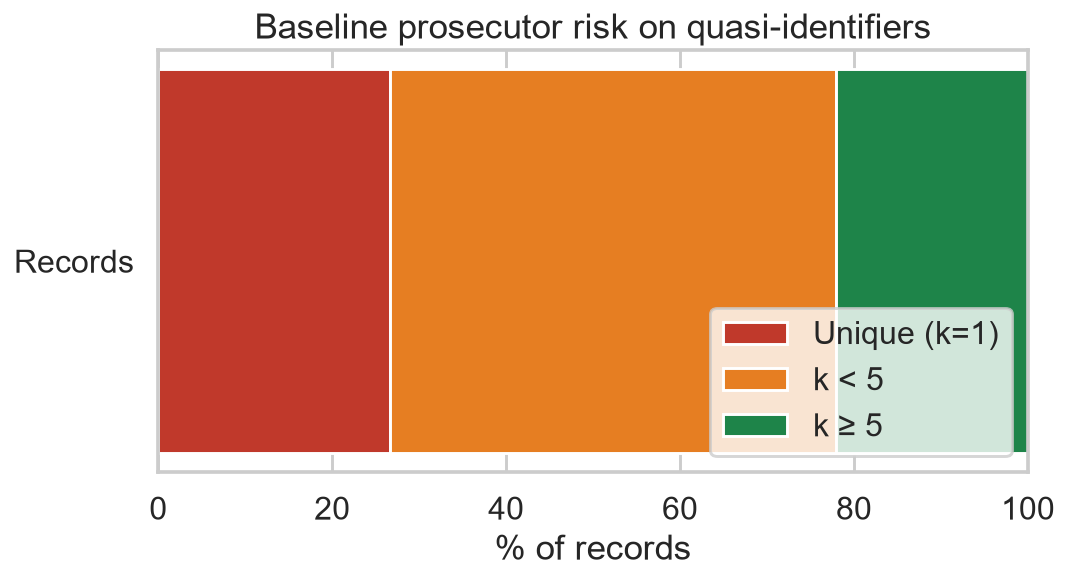

In [9]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS_DIR / "baseline_waffle.png")))

**Class-size histogram (raw data)**

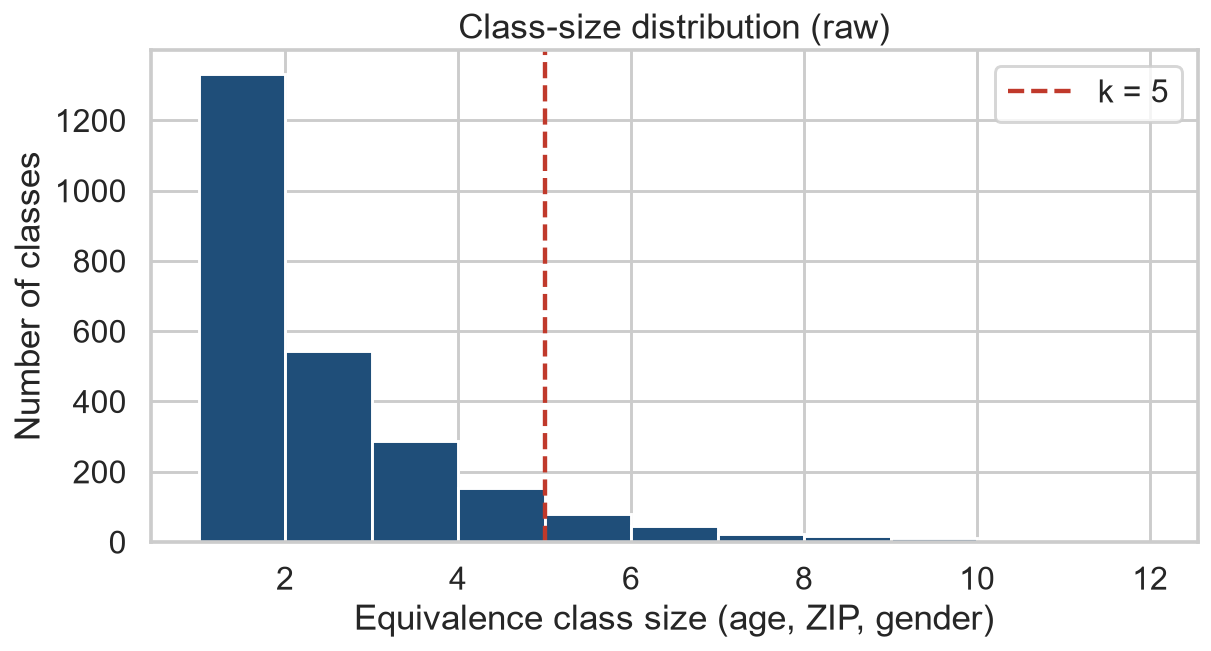

In [10]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS_DIR / "baseline_group_sizes.png")))

**Uniqueness by ZIP prefix**

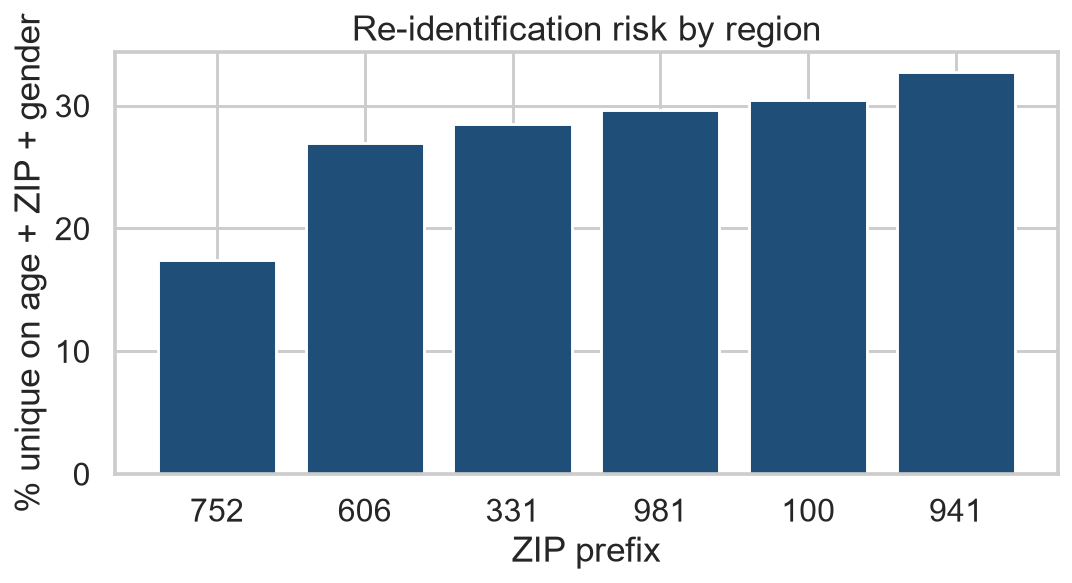

In [11]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS_DIR / "risk_by_region.png")))

**Voter-list join: pseudonymized vs anonymized**

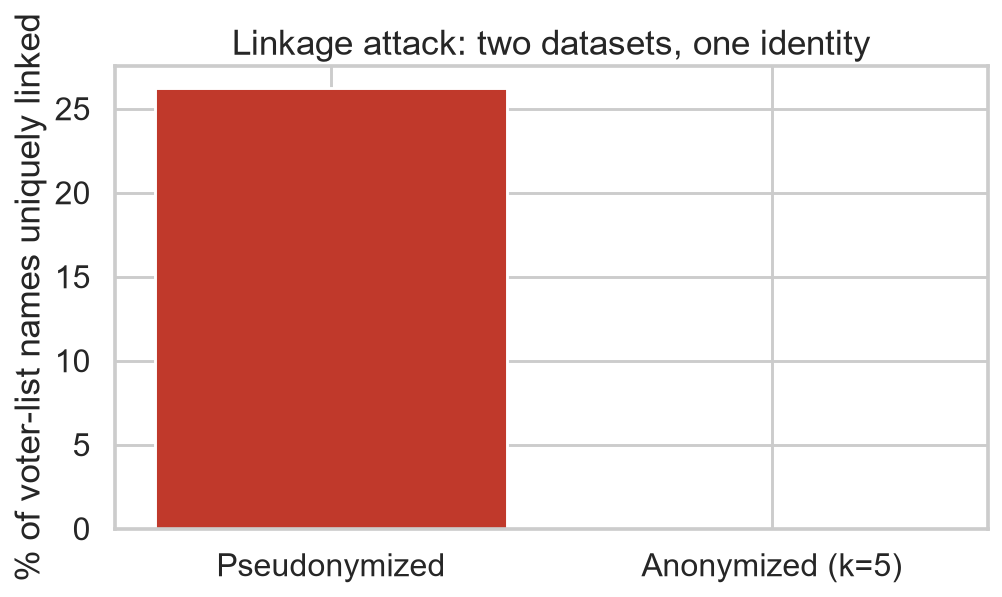

In [12]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS_DIR / "linkage_attack.png")))

**Accuracy lost as k grows**

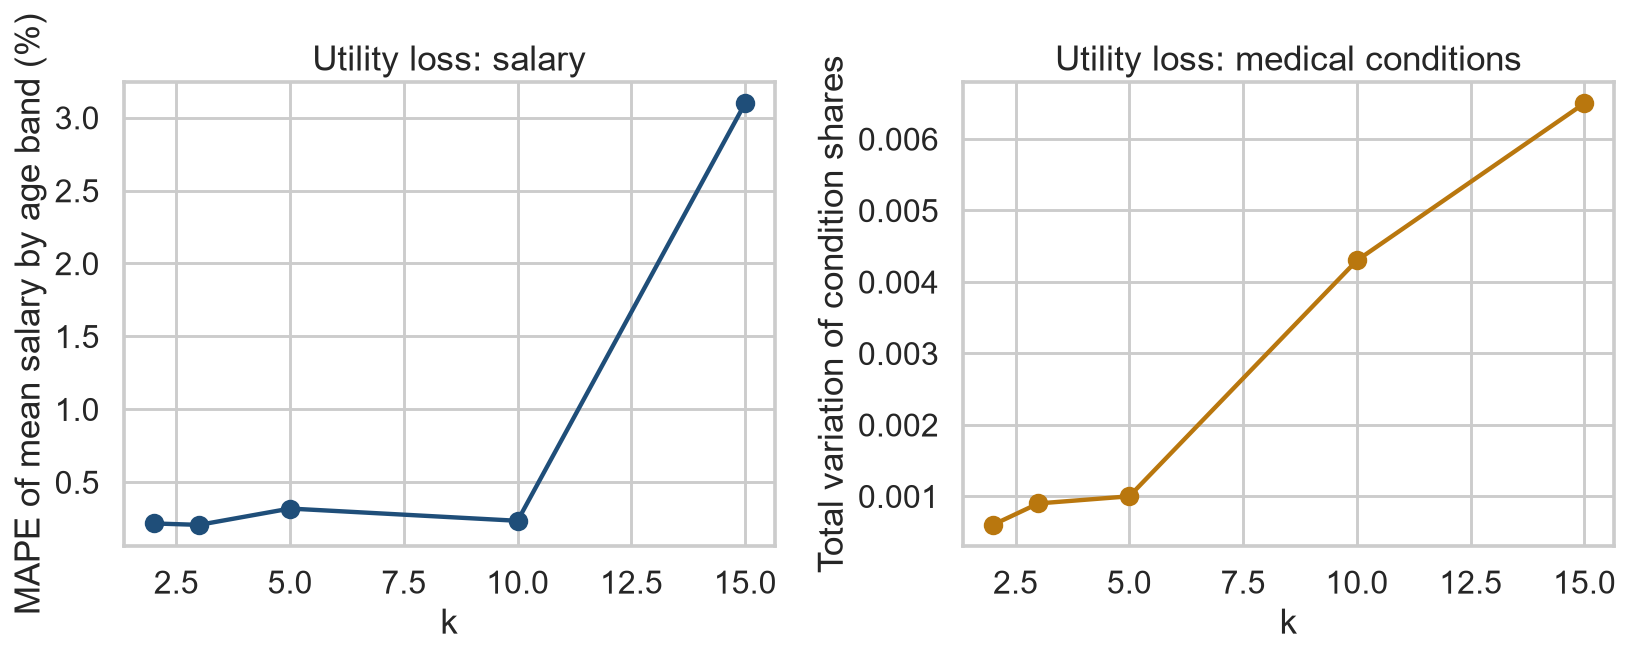

In [13]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS_DIR / "utility_vs_k.png")))

**Records dropped as k grows**

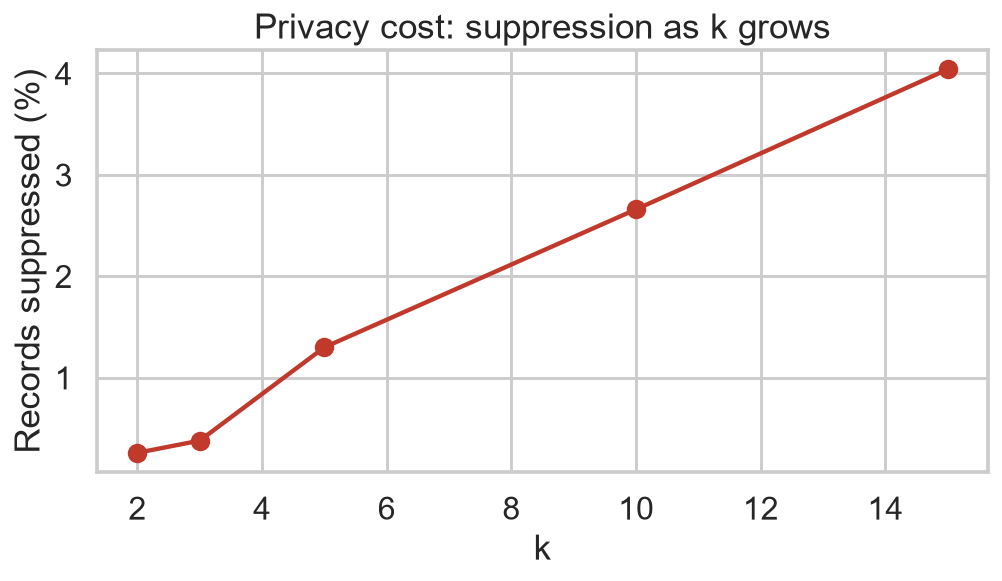

In [14]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS_DIR / "suppression_vs_k.png")))